# Super Store Sales - Probability Distribution (Statistics With R)

### 1. Create the data (30 observations)

In [1]:
set.seed(123)
n <- 30

data <- data.frame(
  Obs          = 1:30,
  Age          = sample(16:81, n, replace = TRUE),
  Sales_Before = sample(10:95, n, replace = TRUE),
  Sales_After  = sample(10:117, n, replace = TRUE),
  Gender       = sample(c(rep(0, 14), rep(1, 16))),      # 0 = Female, 1 = Male
  Profession   = sample(c(rep(0, 15), rep(1, 15)))       # 0 = Executive, 1 = Manager
)

head(data, 10)

,Obs,Age,Sales_Before,Sales_After,Gender,Profession
,<int>,<int>,<int>,<int>,<dbl>,<dbl>
1,1,46,78,34,0,1
2,2,66,81,96,1,1
3,3,29,85,44,1,0
4,4,57,72,49,1,1
5,5,65,22,39,0,1
6,6,58,91,21,0,0
7,7,29,34,40,1,1
8,8,40,47,39,1,0
9,9,72,30,73,1,1


### 2. Probability distribution of number of Executives
Manager selects 10 individuals. P(Executive) = 0.7, P(Manager) = 0.3.
Each person is either Executive or not, so the number of Executives follows a **Binomial distribution** with n = 10 and p = 0.7.

In [2]:
size <- 10
p <- 0.7
x <- 0:9

prob <- dbinom(x, size = size, prob = p)

prob_table <- data.frame(Executives = x, Probability = round(prob, 4),
                         Cumulative = round(pbinom(x, size, p), 4))
prob_table

Executives,Probability,Cumulative
<int>,<dbl>,<dbl>
0,0.0000,0.0000
1,0.0001,0.0001
2,0.0014,0.0016
3,0.0090,0.0106
4,0.0368,0.0473
5,0.1029,0.1503
6,0.2001,0.3504
7,0.2668,0.6172
8,0.2335,0.8507


In [3]:
# Total probability for 0 to 9 and the left-out value (10 Executives)
sum(prob)
dbinom(10, size, p)

[1] 0.9717525

[1] 0.02824752

### 3. Plot the distribution

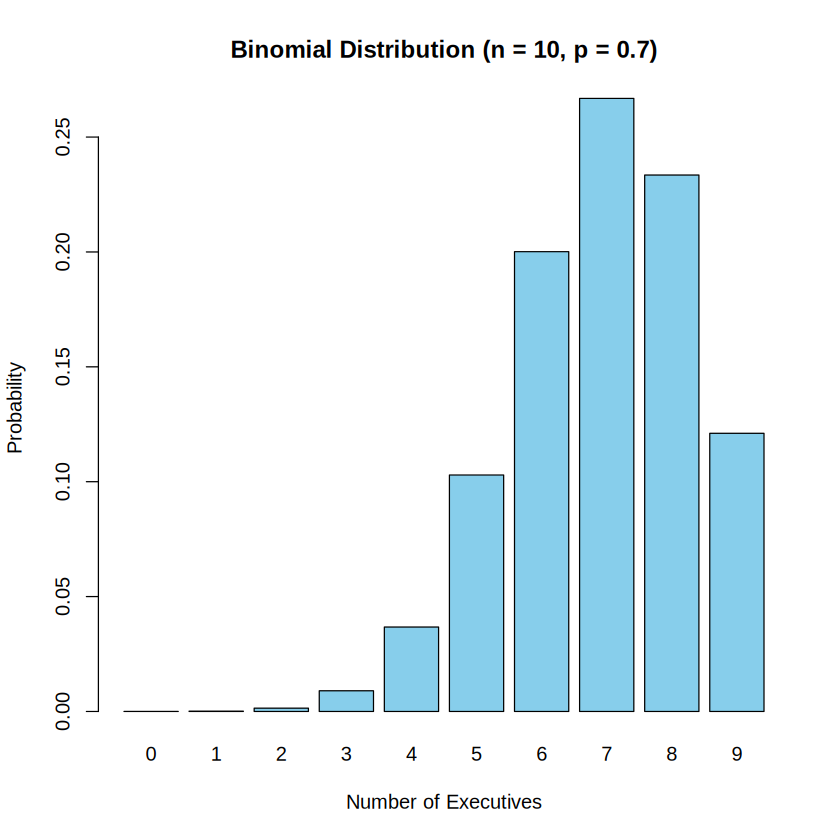

In [4]:
barplot(prob, names.arg = x, col = "skyblue",
        main = "Binomial Distribution (n = 10, p = 0.7)",
        xlab = "Number of Executives", ylab = "Probability")

### 4. Is there any normality?

In [5]:
mean_x <- size * p
sd_x   <- sqrt(size * p * (1 - p))
skew   <- (1 - 2 * p) / sd_x

cat("Mean (np)      :", mean_x, "\n")
cat("SD             :", round(sd_x, 3), "\n")
cat("Skewness       :", round(skew, 3), "\n")
cat("np =", size * p, " and nq =", size * (1 - p), "\n")

Mean (np)      : 7 
SD             : 1.449 
Skewness       : -0.276 
np = 7  and nq = 3 


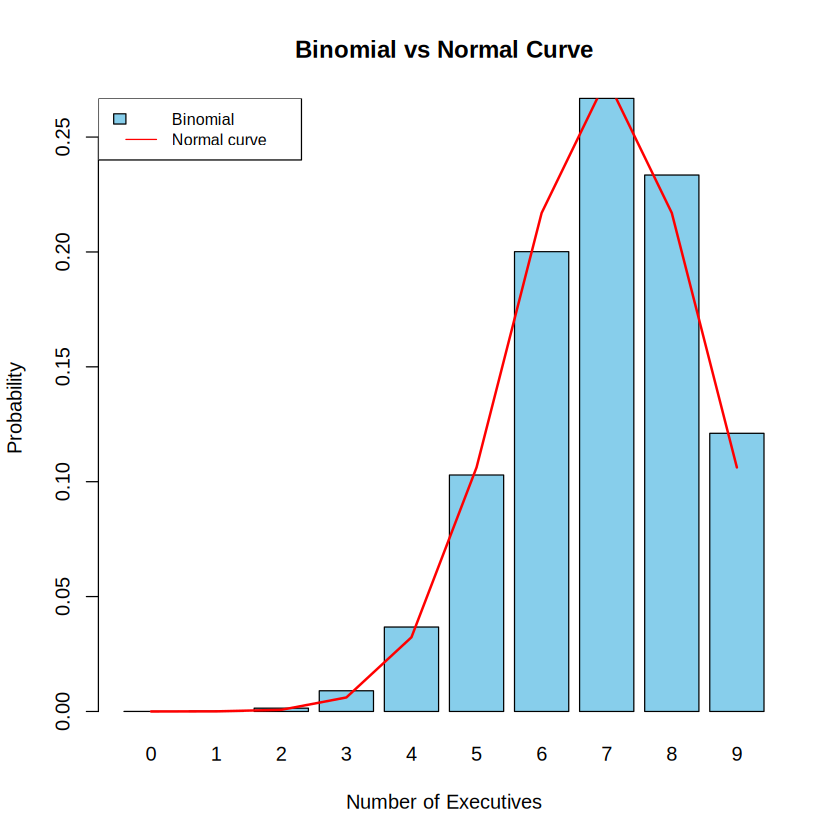

In [6]:
# Compare binomial bars with a normal curve (same mean and SD)
bp <- barplot(prob, names.arg = x, col = "skyblue",
              main = "Binomial vs Normal Curve",
              xlab = "Number of Executives", ylab = "Probability")
lines(bp, dnorm(x, mean = mean_x, sd = sd_x), col = "red", lwd = 2)
legend("topleft", legend = c("Binomial", "Normal curve"),
       fill = c("skyblue", NA), border = c("black", NA),
       lty = c(NA, 1), col = c(NA, "red"), cex = 0.8)

In [7]:
# Example: P(X <= 5) exact vs normal approximation (with continuity correction)
pbinom(5, size, p)
pnorm(5.5, mean = mean_x, sd = sd_x)

[1] 0.1502683

[1] 0.1503115

**Explanation**
- The plot is bell-shaped and peaks around 7 (= np), so it looks roughly normal.
- But it is **not perfectly normal**: the skewness is negative (left skewed) because p = 0.7 is not 0.5, and the bars are limited between 0 and 10.
- Rule of thumb for normal approximation: np >= 5 and nq >= 5. Here np = 7 (OK) but nq = 3 (not OK), so the normal approximation is only rough.
- The exact and normal-approximated probabilities in the last cell are close but not equal.
- With a larger sample (e.g. the planned 2000 customers) the distribution would become much closer to normal.